In [7]:
import pandas as pd

# Load all 6 files
begin_inventory = pd.read_csv("begin_inventory.csv")
end_inventory = pd.read_csv("end_inventory.csv")
purchases = pd.read_csv("purchases.csv")
purchase_prices = pd.read_csv("purchase_prices.csv")
vendor_invoice = pd.read_csv("vendor_invoice.csv")
sales = pd.read_csv("sales.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
print("Begin Inventory:", begin_inventory.shape)
print("End Inventory:", end_inventory.shape)
print("Purchases:", purchases.shape)
print("Purchase Prices:", purchase_prices.shape)
print("Vendor Invoice:", vendor_invoice.shape)
print("Sales:", sales.shape)

Begin Inventory: (206529, 9)
End Inventory: (224489, 9)
Purchases: (2372474, 16)
Purchase Prices: (12261, 9)
Vendor Invoice: (5543, 10)
Sales: (12825363, 14)


In [9]:
print("=== BEGIN INVENTORY ===")
print(begin_inventory.head())

print("\n=== END INVENTORY ===")
print(end_inventory.head())

print("\n=== PURCHASES ===")
print(purchases.head())

print("\n=== PURCHASE PRICES ===")
print(purchase_prices.head())

print("\n=== VENDOR INVOICE ===")
print(vendor_invoice.head())

print("\n=== SALES ===")
print(sales.head())

=== BEGIN INVENTORY ===
         InventoryId  Store          City  Brand                  Description  \
0  1_HARDERSFIELD_58      1  HARDERSFIELD     58  Gekkeikan Black & Gold Sake   
1  1_HARDERSFIELD_60      1  HARDERSFIELD     60       Canadian Club 1858 VAP   
2  1_HARDERSFIELD_62      1  HARDERSFIELD     62     Herradura Silver Tequila   
3  1_HARDERSFIELD_63      1  HARDERSFIELD     63   Herradura Reposado Tequila   
4  1_HARDERSFIELD_72      1  HARDERSFIELD     72         No. 3 London Dry Gin   

    Size  onHand  Price   startDate  
0  750mL       8  12.99  2024-01-01  
1  750mL       7  10.99  2024-01-01  
2  750mL       6  36.99  2024-01-01  
3  750mL       3  38.99  2024-01-01  
4  750mL       6  34.99  2024-01-01  

=== END INVENTORY ===
         InventoryId  Store          City  Brand                  Description  \
0  1_HARDERSFIELD_58      1  HARDERSFIELD     58  Gekkeikan Black & Gold Sake   
1  1_HARDERSFIELD_62      1  HARDERSFIELD     62     Herradura Silver Tequil

In [10]:
print("=== MISSING VALUES ===")
print("\nBegin Inventory:")
print(begin_inventory.isnull().sum())

print("\nEnd Inventory:")
print(end_inventory.isnull().sum())

print("\nPurchases:")
print(purchases.isnull().sum())

print("\nPurchase Prices:")
print(purchase_prices.isnull().sum())

print("\nVendor Invoice:")
print(vendor_invoice.isnull().sum())

print("\nSales:")
print(sales.isnull().sum())

=== MISSING VALUES ===

Begin Inventory:
InventoryId    0
Store          0
City           0
Brand          0
Description    0
Size           0
onHand         0
Price          0
startDate      0
dtype: int64

End Inventory:
InventoryId       0
Store             0
City           1284
Brand             0
Description       0
Size              0
onHand            0
Price             0
endDate           0
dtype: int64

Purchases:
InventoryId       0
Store             0
Brand             0
Description       0
Size              3
VendorNumber      0
VendorName        0
PONumber          0
PODate            0
ReceivingDate     0
InvoiceDate       0
PayDate           0
PurchasePrice     0
Quantity          0
Dollars           0
Classification    0
dtype: int64

Purchase Prices:
Brand             0
Description       1
Price             0
Size              1
Volume            1
Classification    0
PurchasePrice     0
VendorNumber      0
VendorName        0
dtype: int64

Vendor Invoice:
VendorNumbe

In [11]:
# Fix missing City in end_inventory
city_map = begin_inventory[['Store', 'City']].drop_duplicates().set_index('Store')['City']
end_inventory['City'] = end_inventory['City'].fillna(end_inventory['Store'].map(city_map))

# Verify fix
print("Missing Cities after fix:", end_inventory['City'].isnull().sum())

Missing Cities after fix: 0


In [12]:
print("=== DATA TYPES ===")
print("\nBegin Inventory:")
print(begin_inventory.dtypes)

print("\nEnd Inventory:")
print(end_inventory.dtypes)

print("\nPurchases:")
print(purchases.dtypes)

print("\nPurchase Prices:")
print(purchase_prices.dtypes)

print("\nVendor Invoice:")
print(vendor_invoice.dtypes)

print("\nSales:")
print(sales.dtypes)

=== DATA TYPES ===

Begin Inventory:
InventoryId        str
Store            int64
City               str
Brand            int64
Description        str
Size               str
onHand           int64
Price          float64
startDate          str
dtype: object

End Inventory:
InventoryId        str
Store            int64
City               str
Brand            int64
Description        str
Size               str
onHand           int64
Price          float64
endDate            str
dtype: object

Purchases:
InventoryId           str
Store               int64
Brand               int64
Description           str
Size                  str
VendorNumber        int64
VendorName            str
PONumber            int64
PODate                str
ReceivingDate         str
InvoiceDate           str
PayDate               str
PurchasePrice     float64
Quantity            int64
Dollars           float64
Classification      int64
dtype: object

Purchase Prices:
Brand               int64
Description        

In [13]:
# Fix date columns
begin_inventory['startDate'] = pd.to_datetime(begin_inventory['startDate'])
end_inventory['endDate'] = pd.to_datetime(end_inventory['endDate'])
purchases['PODate'] = pd.to_datetime(purchases['PODate'])
purchases['ReceivingDate'] = pd.to_datetime(purchases['ReceivingDate'])
purchases['InvoiceDate'] = pd.to_datetime(purchases['InvoiceDate'])
purchases['PayDate'] = pd.to_datetime(purchases['PayDate'])
sales['SalesDate'] = pd.to_datetime(sales['SalesDate'])

print("Date columns fixed!")

Date columns fixed!


In [14]:
# Verify
print(begin_inventory['startDate'].dtype)
print(end_inventory['endDate'].dtype)
print(purchases['PODate'].dtype)
print(sales['SalesDate'].dtype)

datetime64[us]
datetime64[us]
datetime64[us]
datetime64[us]


In [15]:
# Key business metrics
print("=== KEY BUSINESS METRICS ===")

print("\nTotal Products in Begin Inventory:", len(begin_inventory))
print("Total Products in End Inventory:", len(end_inventory))

print("\nTotal Purchase Transactions:", len(purchases))
print("Total Purchase Value: $", round(purchases['Dollars'].sum(), 2))

print("\nTotal Sales Transactions:", len(sales))
print("Total Sales Revenue: $", round(sales['SalesDollars'].sum(), 2))

print("\nTotal Unique Vendors:", purchases['VendorName'].nunique())
print("Total Unique Stores:", sales['Store'].nunique())
print("Total Unique Brands:", purchases['Brand'].nunique())

=== KEY BUSINESS METRICS ===

Total Products in Begin Inventory: 206529
Total Products in End Inventory: 224489

Total Purchase Transactions: 2372474
Total Purchase Value: $ 321900765.53

Total Sales Transactions: 12825363
Total Sales Revenue: $ 452062952.02

Total Unique Vendors: 129
Total Unique Stores: 80
Total Unique Brands: 10664


In [16]:
# Top 10 Vendors by Purchase Value
top_vendors = purchases.groupby('VendorName')['Dollars'].sum().sort_values(ascending=False).head(10).reset_index()
top_vendors.columns = ['Vendor', 'Total_Purchase_Value']
top_vendors['Total_Purchase_Value'] = top_vendors['Total_Purchase_Value'].round(2)
print("=== TOP 10 VENDORS BY PURCHASE VALUE ===")
print(top_vendors.to_string(index=False))

=== TOP 10 VENDORS BY PURCHASE VALUE ===
                     Vendor  Total_Purchase_Value
DIAGEO NORTH AMERICA INC              50959796.85
      MARTIGNETTI COMPANIES           27821473.91
JIM BEAM BRANDS COMPANY               24203151.05
PERNOD RICARD USA                     24124091.56
BACARDI USA INC                       17624378.72
CONSTELLATION BRANDS INC              15573917.90
BROWN-FORMAN CORP                     13529433.08
ULTRA BEVERAGE COMPANY LLP            13210613.93
E & J GALLO WINERY                    12289608.09
M S WALKER INC                        10935817.30


Matplotlib is building the font cache; this may take a moment.
/var/folders/nj/vvy6jrx15dx2m2y3xjv3bybr0000gn/T/ipykernel_52407/2744671104.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_vendors, x='Total_Purchase_Value', y='Vendor', palette='Blues_r')


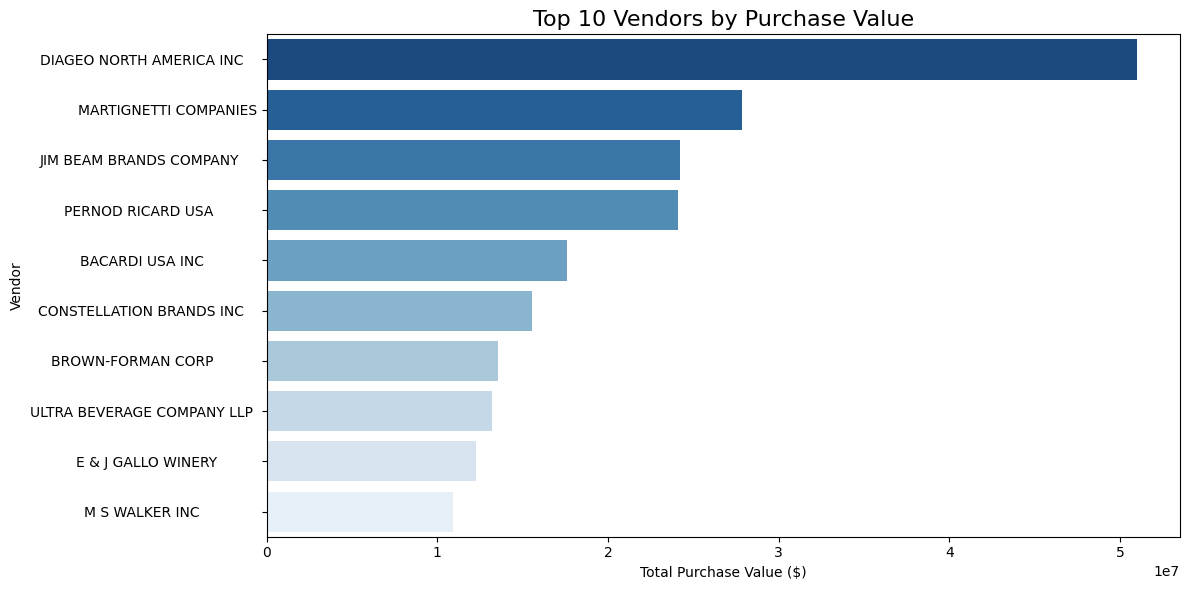

Chart saved as top_vendors.png!


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Top 10 Vendors
plt.figure(figsize=(12, 6))
sns.barplot(data=top_vendors, x='Total_Purchase_Value', y='Vendor', palette='Blues_r')
plt.title('Top 10 Vendors by Purchase Value', fontsize=16)
plt.xlabel('Total Purchase Value ($)')
plt.ylabel('Vendor')
plt.tight_layout()
plt.savefig('top_vendors.png')
plt.show()

print("Chart saved as top_vendors.png!")

In [18]:
# Merge purchases with sales to find vendor sales performance
vendor_sales = purchases.groupby('VendorName')['Dollars'].sum().reset_index()
vendor_sales.columns = ['Vendor', 'Purchase_Value']

# Calculate profit margin per vendor
vendor_sales['Purchase_Value'] = vendor_sales['Purchase_Value'].round(2)

# Top 10 vendors by purchase volume
top_10 = vendor_sales.sort_values('Purchase_Value', ascending=False).head(10)

# Now let's find purchase frequency (how many orders per vendor)
vendor_frequency = purchases.groupby('VendorName')['PONumber'].nunique().reset_index()
vendor_frequency.columns = ['Vendor', 'Total_Orders']

# Merge both
vendor_summary = top_10.merge(vendor_frequency, on='Vendor')
print("=== VENDOR SUMMARY ===")
print(vendor_summary.to_string(index=False))

=== VENDOR SUMMARY ===
                     Vendor  Purchase_Value  Total_Orders
DIAGEO NORTH AMERICA INC        50959796.85            55
      MARTIGNETTI COMPANIES     27821473.91            55
JIM BEAM BRANDS COMPANY         24203151.05            55
PERNOD RICARD USA               24124091.56            55
BACARDI USA INC                 17624378.72            55
CONSTELLATION BRANDS INC        15573917.90            55
BROWN-FORMAN CORP               13529433.08            55
ULTRA BEVERAGE COMPANY LLP      13210613.93            55
E & J GALLO WINERY              12289608.09            55
M S WALKER INC                  10935817.30            55


In [19]:
# Calculate delivery time for each purchase (days between PO date and receiving date)
purchases['Delivery_Days'] = (purchases['ReceivingDate'] - purchases['PODate']).dt.days

# Average delivery days per vendor
delivery_performance = purchases.groupby('VendorName')['Delivery_Days'].mean().round(2).reset_index()
delivery_performance.columns = ['Vendor', 'Avg_Delivery_Days']

# Top 10 vendors only
top_vendor_names = top_10['Vendor'].tolist()
delivery_top10 = delivery_performance[delivery_performance['Vendor'].isin(top_vendor_names)]
delivery_top10 = delivery_top10.sort_values('Avg_Delivery_Days')

print("=== VENDOR DELIVERY PERFORMANCE ===")
print(delivery_top10.to_string(index=False))

=== VENDOR DELIVERY PERFORMANCE ===
                     Vendor  Avg_Delivery_Days
JIM BEAM BRANDS COMPANY                   7.51
BROWN-FORMAN CORP                         7.55
DIAGEO NORTH AMERICA INC                  7.55
PERNOD RICARD USA                         7.56
E & J GALLO WINERY                        7.62
BACARDI USA INC                           7.70
CONSTELLATION BRANDS INC                  7.74
      MARTIGNETTI COMPANIES               7.79
M S WALKER INC                            7.91
ULTRA BEVERAGE COMPANY LLP                8.41


/var/folders/nj/vvy6jrx15dx2m2y3xjv3bybr0000gn/T/ipykernel_52407/3636835687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivery_top10, x='Avg_Delivery_Days', y='Vendor', palette='RdYlGn_r')


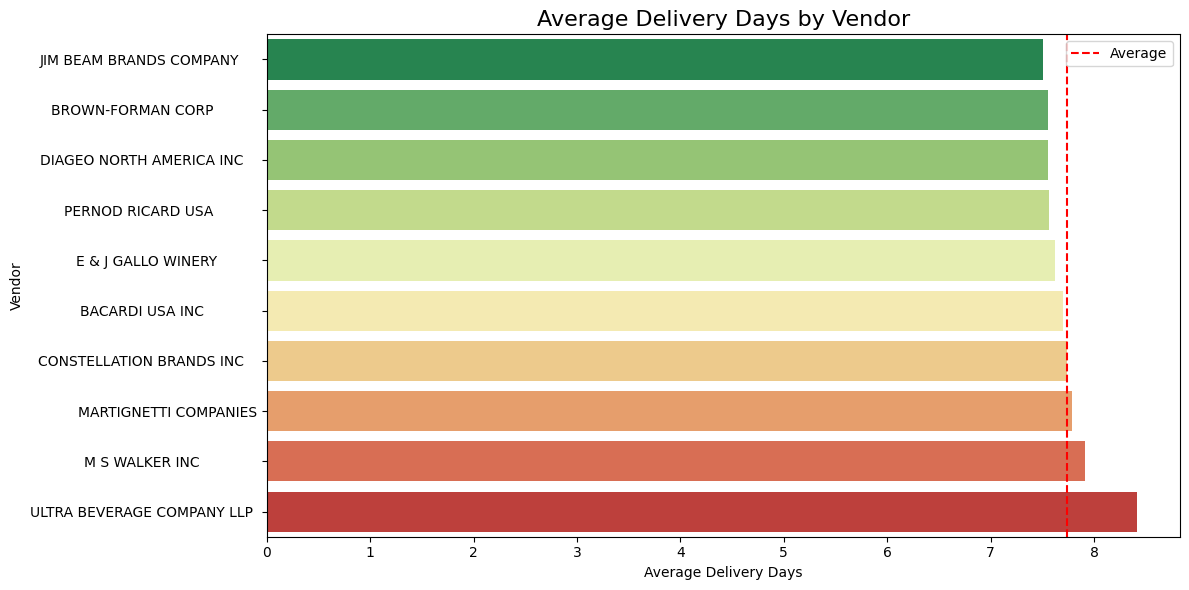

Chart saved!


In [20]:
# Plot Delivery Performance
plt.figure(figsize=(12, 6))
sns.barplot(data=delivery_top10, x='Avg_Delivery_Days', y='Vendor', palette='RdYlGn_r')
plt.title('Average Delivery Days by Vendor', fontsize=16)
plt.xlabel('Average Delivery Days')
plt.ylabel('Vendor')
plt.axvline(x=delivery_top10['Avg_Delivery_Days'].mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.savefig('delivery_performance.png')
plt.show()

print("Chart saved!")

In [22]:
# Merge purchase prices with purchases
price_analysis = purchases.groupby('VendorName').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Dollars=('Dollars', 'sum'),
    Total_Volume=('Volume', 'sum')
).reset_index()

# Calculate average price per unit
price_analysis['Avg_Price_Per_Unit'] = (price_analysis['Total_Dollars'] / price_analysis['Total_Quantity']).round(2)

# Filter top 10 vendors
price_top10 = price_analysis[price_analysis['VendorName'].isin(top_vendor_names)]
price_top10 = price_top10.sort_values('Avg_Price_Per_Unit')

print("=== VENDOR PRICING ANALYSIS ===")
print(price_top10[['VendorName', 'Total_Quantity', 'Total_Dollars', 'Avg_Price_Per_Unit']].to_string(index=False))

KeyError: "Label(s) ['Volume'] do not exist"

In [23]:
print(purchases.columns.tolist())

['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'VendorNumber', 'VendorName', 'PONumber', 'PODate', 'ReceivingDate', 'InvoiceDate', 'PayDate', 'PurchasePrice', 'Quantity', 'Dollars', 'Classification', 'Delivery_Days']


In [24]:
# Vendor Pricing Analysis
price_analysis = purchases.groupby('VendorName').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Dollars=('Dollars', 'sum'),
    Avg_Price_Per_Unit=('PurchasePrice', 'mean')
).reset_index()

price_analysis['Avg_Price_Per_Unit'] = price_analysis['Avg_Price_Per_Unit'].round(2)

# Filter top 10 vendors
price_top10 = price_analysis[price_analysis['VendorName'].isin(top_vendor_names)]
price_top10 = price_top10.sort_values('Avg_Price_Per_Unit')

print("=== VENDOR PRICING ANALYSIS ===")
print(price_top10[['VendorName', 'Total_Quantity', 'Total_Dollars', 'Avg_Price_Per_Unit']].to_string(index=False))

=== VENDOR PRICING ANALYSIS ===
                 VendorName  Total_Quantity  Total_Dollars  Avg_Price_Per_Unit
CONSTELLATION BRANDS INC            2325892    15573917.90                7.10
E & J GALLO WINERY                  1858260    12289608.09                7.26
M S WALKER INC                      1372841    10935817.30                8.68
      MARTIGNETTI COMPANIES         2637275    27821473.91               11.08
JIM BEAM BRANDS COMPANY             2737165    24203151.05               12.88
BACARDI USA INC                     1427075    17624378.72               14.26
ULTRA BEVERAGE COMPANY LLP          1077527    13210613.93               15.81
DIAGEO NORTH AMERICA INC            5459788    50959796.85               16.11
BROWN-FORMAN CORP                   1006122    13529433.08               18.30
PERNOD RICARD USA                   1647558    24124091.56               18.61


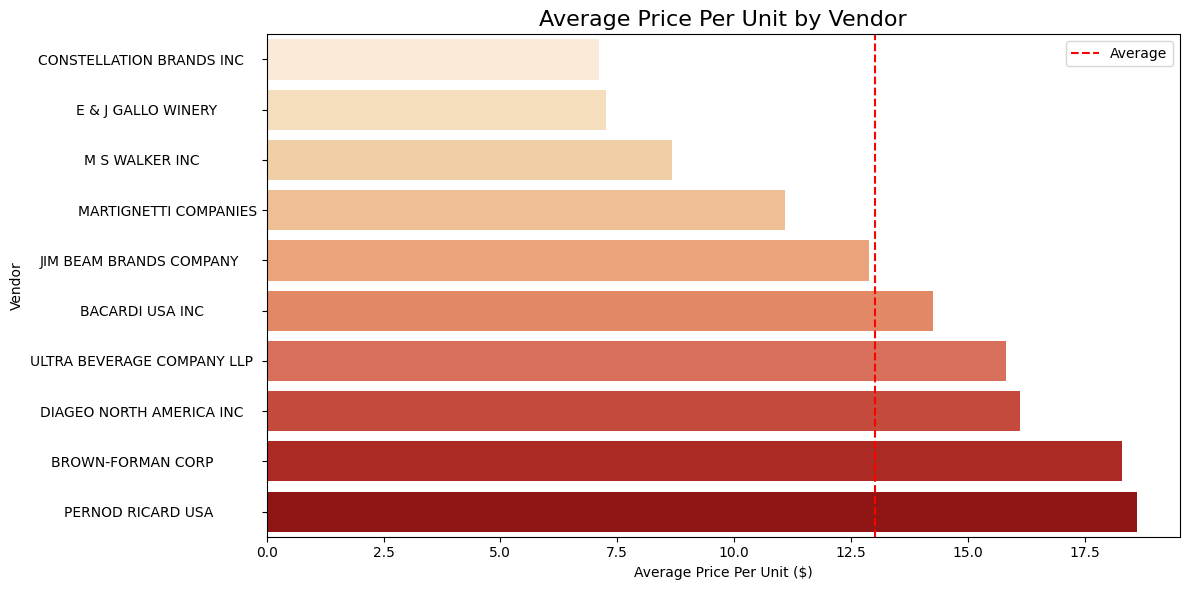

Chart saved!


In [25]:
# Plot Vendor Pricing Analysis
plt.figure(figsize=(12, 6))
sns.barplot(data=price_top10, x='Avg_Price_Per_Unit', y='VendorName', palette='OrRd', hue='VendorName', legend=False)
plt.title('Average Price Per Unit by Vendor', fontsize=16)
plt.xlabel('Average Price Per Unit ($)')
plt.ylabel('Vendor')
plt.axvline(x=price_top10['Avg_Price_Per_Unit'].mean(), color='red', linestyle='--', label='Average')
plt.legend()
plt.tight_layout()
plt.savefig('vendor_pricing.png')
plt.show()

print("Chart saved!")

In [26]:
# Build Complete Vendor Scorecard
scorecard = price_top10[['VendorName', 'Total_Quantity', 'Total_Dollars', 'Avg_Price_Per_Unit']].copy()

# Add delivery days
delivery_dict = delivery_top10.set_index('Vendor')['Avg_Delivery_Days'].to_dict()
scorecard['Avg_Delivery_Days'] = scorecard['VendorName'].map(delivery_dict)

# Add total orders
orders_dict = vendor_summary.set_index('Vendor')['Total_Orders'].to_dict()
scorecard['Total_Orders'] = scorecard['VendorName'].map(orders_dict)

# Score each vendor (lower delivery = better, lower price = better)
scorecard['Delivery_Score'] = (scorecard['Avg_Delivery_Days'].max() - scorecard['Avg_Delivery_Days']).round(2)
scorecard['Price_Score'] = (scorecard['Avg_Price_Per_Unit'].max() - scorecard['Avg_Price_Per_Unit']).round(2)
scorecard['Volume_Score'] = (scorecard['Total_Quantity'] / scorecard['Total_Quantity'].max()).round(2)

# Overall score
scorecard['Overall_Score'] = (scorecard['Delivery_Score'] + scorecard['Price_Score'] + scorecard['Volume_Score']).round(2)
scorecard = scorecard.sort_values('Overall_Score', ascending=False)

print("=== VENDOR PERFORMANCE SCORECARD ===")
print(scorecard[['VendorName', 'Avg_Delivery_Days', 'Avg_Price_Per_Unit', 'Total_Quantity', 'Overall_Score']].to_string(index=False))

=== VENDOR PERFORMANCE SCORECARD ===
                 VendorName  Avg_Delivery_Days  Avg_Price_Per_Unit  Total_Quantity  Overall_Score
CONSTELLATION BRANDS INC                  7.74                7.10         2325892          12.61
E & J GALLO WINERY                        7.62                7.26         1858260          12.48
M S WALKER INC                            7.91                8.68         1372841          10.68
      MARTIGNETTI COMPANIES               7.79               11.08         2637275           8.63
JIM BEAM BRANDS COMPANY                   7.51               12.88         2737165           7.13
BACARDI USA INC                           7.70               14.26         1427075           5.32
DIAGEO NORTH AMERICA INC                  7.55               16.11         5459788           4.36
ULTRA BEVERAGE COMPANY LLP                8.41               15.81         1077527           3.00
BROWN-FORMAN CORP                         7.55               18.30         100612

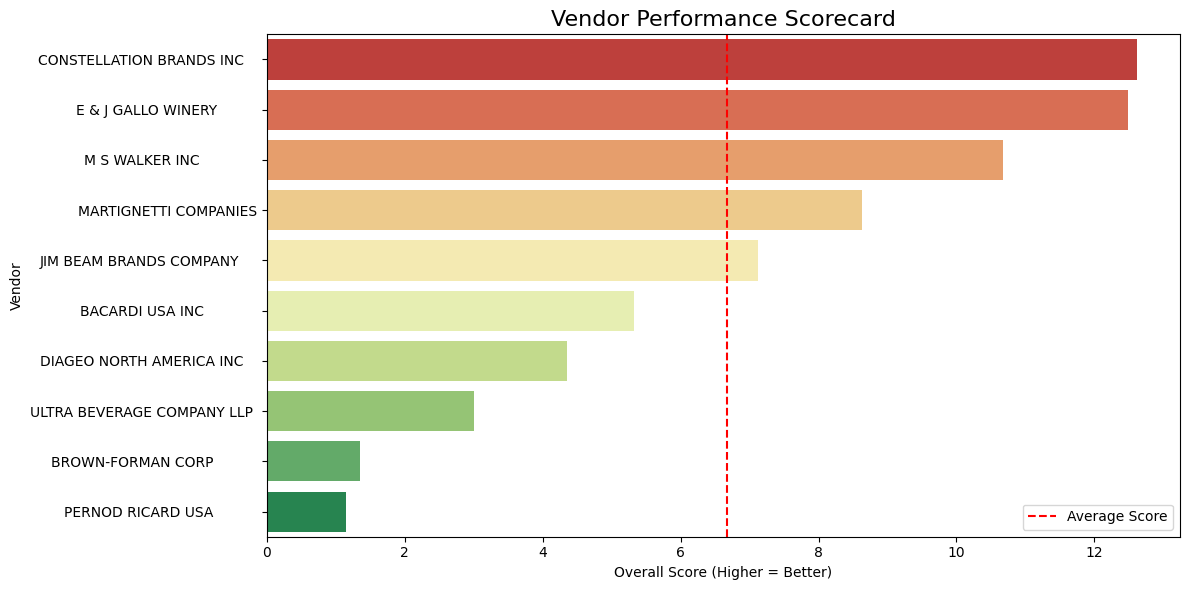

Scorecard chart saved!


In [27]:
# Plot Vendor Performance Scorecard
plt.figure(figsize=(12, 6))
sns.barplot(data=scorecard, x='Overall_Score', y='VendorName', 
            hue='VendorName', legend=False, palette='RdYlGn')
plt.title('Vendor Performance Scorecard', fontsize=16)
plt.xlabel('Overall Score (Higher = Better)')
plt.ylabel('Vendor')
plt.axvline(x=scorecard['Overall_Score'].mean(), color='red', 
            linestyle='--', label='Average Score')
plt.legend()
plt.tight_layout()
plt.savefig('vendor_scorecard.png')
plt.show()

print("Scorecard chart saved!")